# Annihilation profile Heatmaps

In [1]:
import sys
sys.path.insert(0, r'C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Programming')

# Packages
import numpy as np
import matplotlib.pyplot as plt

# Files importation
from pals_analysis import config
from pals_analysis.physics.implantation import makhov_profile
from pals_analysis.physics.annihilation import calculate_annihilation_profile
from pals_analysis.analysis.thickness_solver import numerical_S_curve
from pals_analysis.visualization.plots import create_heatmap
from pals_analysis.visualization import setup_plot_style

# Setting plotting style
plt.rcParams.update({
        'figure.figsize': (10, 6),
        'font.size': 11,
        'axes.labelsize': 12,
        'axes.titlesize': 14,
        'legend.fontsize': 10,
        'figure.dpi': 100,
        'savefig.dpi': 300,
        'grid.alpha': 0.3,
    })


# Define energies we are probing
energies = np.linspace(5, 25, 100)  # in keV
energies_line = np.array([3,8,10,20])

In [2]:
def thickness_layer(layers):
    depth = 0
    i = 0
    for i in range(len(layers)):
        depth += layers[i]['thickness']
        i += 1
    
    return depth

# We define the layers we will be using.
# We also configure the grid and which one to use based its depth
# The function thickness_layer calculates the depth of each created layer.

layers_steel = [
    {'thickness': 1000, 'density': 8.00, 'L_diff': 150, 'S_param': 0.515}  # Steel (Substrate)
    ]

z_pts = 2000 # fineness of the grid

z_grid_steel = np.linspace(0, thickness_layer(layers_steel), z_pts)

[0.00000000e+00 1.00050025e+00 2.00100050e+00 ... 1.99799900e+03
 1.99899950e+03 2.00000000e+03]
Saved: heatmap_sharp.pdf
Saved: heatmap_sharp.pdf


ValueError: operands could not be broadcast together with shapes (2000,) (100,) (100,2000) 

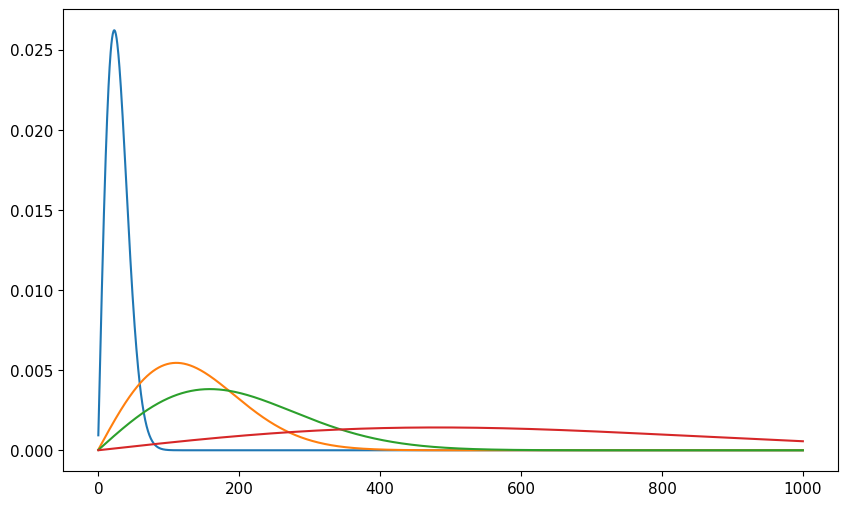

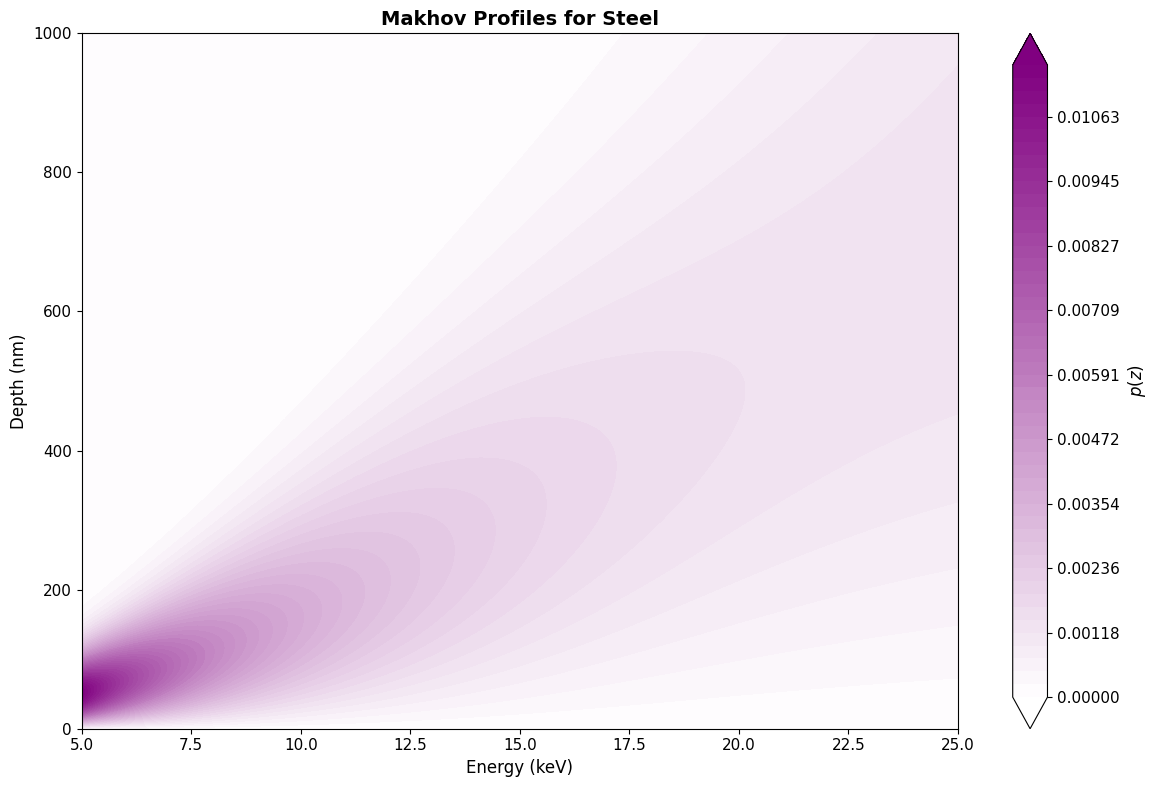

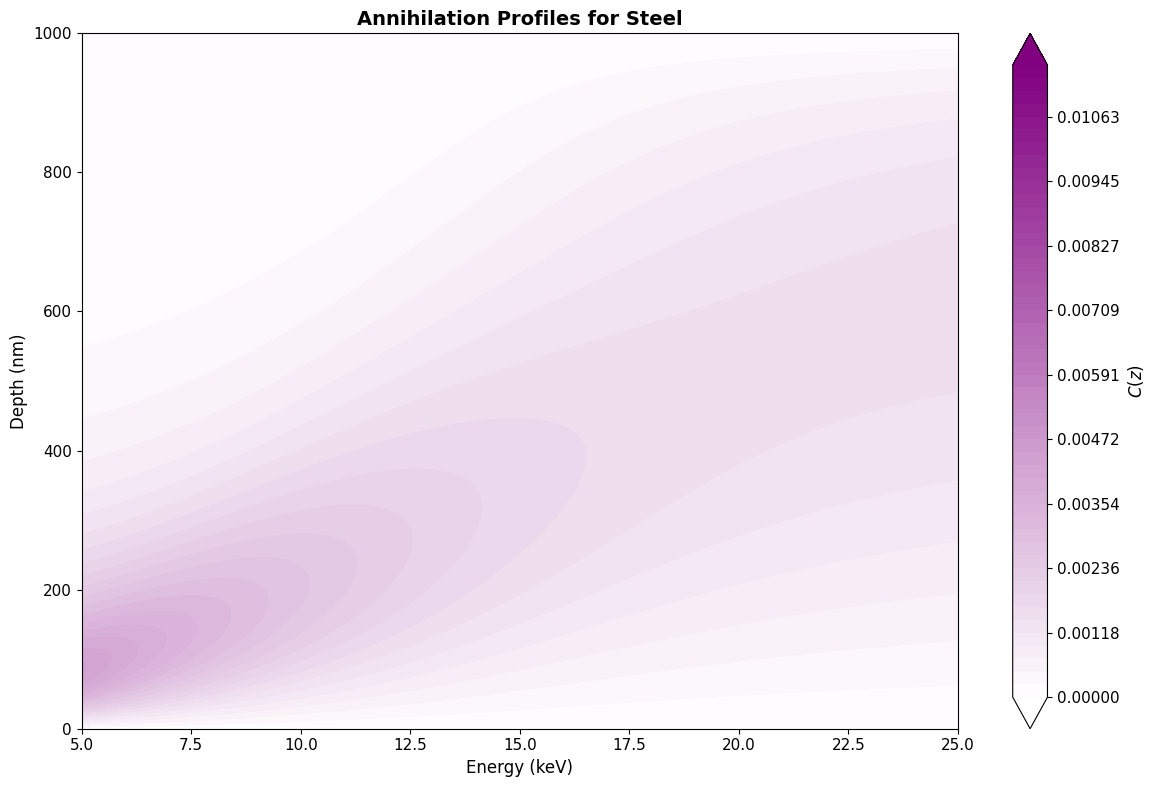

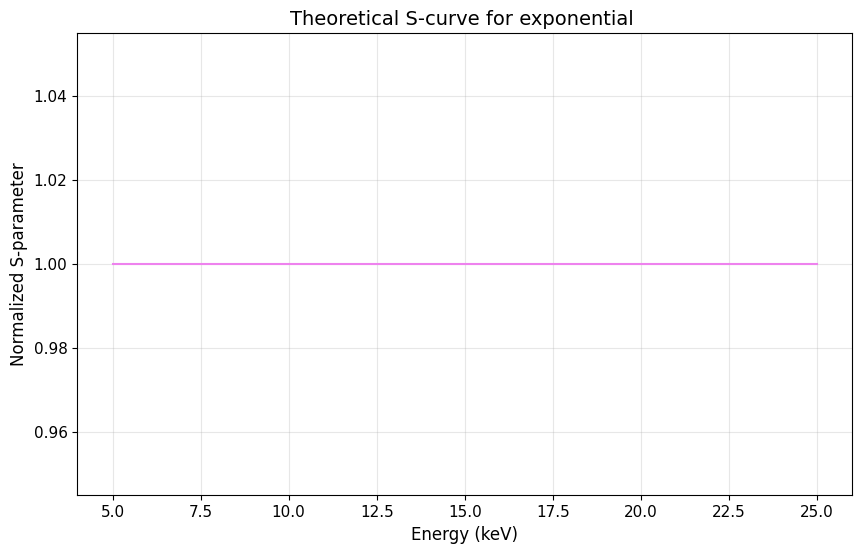

In [3]:
print(np.linspace(0, len(z_grid_steel), z_pts))
S = 0.52*np.exp((-1)*np.linspace(0, len(z_grid_steel), z_pts))

S = np.zeros_like(z_grid_steel)+0.52

matrix_sharp_steel = []
matrix_sharp_steel_diffused = []
s = []
s_d = []
for E in energies:
# Run Sharp (Standard)
    p_s = makhov_profile(z_grid_steel, E, layers_steel, model='layered')
    c_s = calculate_annihilation_profile(z_grid_steel, p_s, layers_steel, model="layered")
    matrix_sharp_steel.append(p_s)
    s_point = np.trapezoid(c_s * S, z_grid_steel)
    s.append(s_point)
    matrix_sharp_steel_diffused.append(c_s)


matrix_sharp_steel_line = []
plt.figure()
s_line = []
for E in energies_line:
# Run Sharp (Standard)
    p_s = makhov_profile(z_grid_steel, E, layers_steel, model='layered')
    plt.plot(z_grid_steel, p_s)
    matrix_sharp_steel_line.append(p_s)


matrix_sharp_steel = np.array(matrix_sharp_steel)
matrix_sharp_steel_diffused = np.array(matrix_sharp_steel_diffused)
s = np.array(s)

create_heatmap(
        energies, z_grid_steel, matrix_sharp_steel,
        title="Makhov Profiles for Steel",
        save_as="heatmap_sharp.pdf",cbar_label=r'$p(z)$'
    )

ref_range = (matrix_sharp_steel.min(), matrix_sharp_steel.max())
create_heatmap(
        energies, z_grid_steel, matrix_sharp_steel_diffused, v_range=ref_range,
        title="Annihilation Profiles for Steel",
        save_as="heatmap_sharp.pdf",cbar_label=r'$C(z)$'
    )

S_e = np.trapezoid(matrix_sharp_steel_diffused, z_grid_steel, axis=1)
plt.figure()
plt.xlabel("Energy (keV)")
plt.ylabel("Normalized S-parameter")
plt.title("Theoretical S-curve for exponential ")
plt.grid("True")
plt.plot(energies, S_e, label="Uniform S-parameter", color="violet")

S_d = np.divide(np.trapezoid(matrix_sharp_steel_diffused * S, energies, axis=0), np.trapezoid(matrix_sharp_steel_diffused, z_grid_steel, axis=1), where=matrix_sharp_steel_diffused!=0)
plt.figure()
plt.xlabel("Depth (nm)")
plt.ylabel("Normalized S-parameter density")
plt.title("Theoretical S-curve for constant S-parameter ")
plt.grid("True")
plt.plot(z_grid_steel, S_d, label="Uniform S-parameter", color="purple")



# Differing oxide layer thickness and fractional oxidation

Here we try different simulation to see if the simulation infers some findings.

In [57]:

# Define energies we are probing
energies = np.linspace(0.1, 25, 100)  # in keV

def thickness_layer(layers):
    depth = 0
    i = 0
    for i in range(len(layers)):
        depth += layers[i]['thickness']
        i += 1
    
    return depth

# We define the layers we will be using.
# We also configure the grid and which one to use based its depth
# The function thickness_layer calculates the depth of each created layer.

# The "Master" Oxide Definition (Derived from the Orange Curve)
# We assume the CHEMISTRY is the same for all samples.
layer_defs = {
    'surface':  {'density': 6.0,  'L_diff': 5,  'S_param': 0.565}, # Common surface
    'fe_oxide': {'density': 5.24, 'L_diff': 10, 'S_param': 0.590}, # The Porous Outer
    'cr_oxide': {'density': 5.22, 'L_diff': 30, 'S_param': 0.550}, # The Dense Inner
    'bulk':     {'density': 8.00, 'L_diff': 150,'S_param': 0.515}  # The Steel
}

# Now we only change the GROWTH (Thickness)
# Scenario 1: Orange ("Dirty" Argon) -> THICK
layers_1AA = [
    {**layer_defs['surface'],  'thickness': 2.0},
    {**layer_defs['fe_oxide'], 'thickness': 60.0}, # Thick outer layer
    {**layer_defs['cr_oxide'], 'thickness': 40.0},
    {**layer_defs['bulk'],     'thickness': 2000.0}
]

# Scenario 2: Green ("Clean" Argon) -> THIN
layers_3AA = [
    {**layer_defs['surface'],  'thickness': 2.0},
    {**layer_defs['fe_oxide'], 'thickness': 15.0}, # Much thinner!
    {**layer_defs['cr_oxide'], 'thickness': 15.0},
    {**layer_defs['bulk'],     'thickness': 2000.0}
]

# Scenario 3: Blue (Vacuum) -> THINNEST
layers_3VA = [
    {**layer_defs['surface'],  'thickness': 2.0},
    {**layer_defs['fe_oxide'], 'thickness': 5.0},  # Barely there
    {**layer_defs['cr_oxide'], 'thickness': 10.0},
    {**layer_defs['bulk'],     'thickness': 2000.0}
]

z_pts = 2000 # fineness of the grid

aa = thickness_layer(layers_steel)
a = thickness_layer(layers_1AA)
b = thickness_layer(layers_3AA)
c = thickness_layer(layers_3VA)

d_max = max(a,b,c,aa)
print(d_max)

z_grid = np.linspace(0, d_max, z_pts)

2102.0


Calculating S-curve based on layers and energies...
Calculating S-curve based on layers and energies...
Calculating S-curve based on layers and energies...
Calculating S-curve based on layers and energies...
Saved: heatmap_sharp.pdf
Saved: heatmap_sharp.pdf
Saved: heatmap_sharp.pdf
Saved: heatmap_sharp.pdf


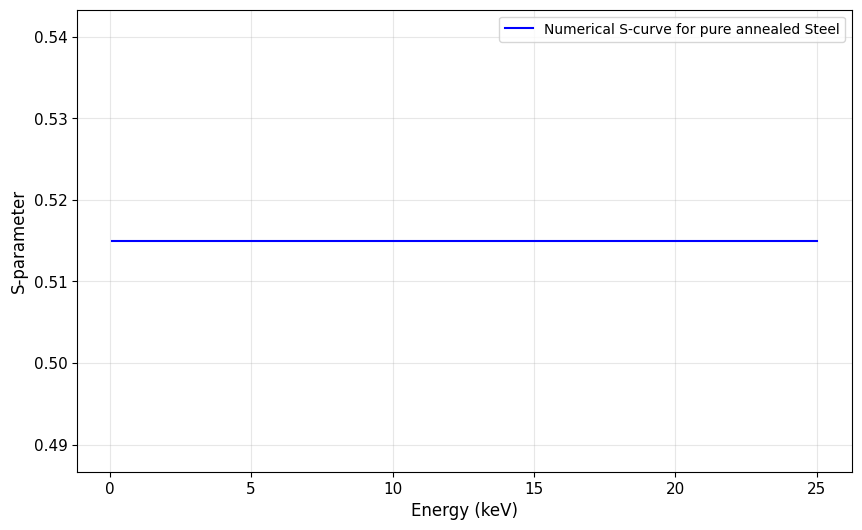

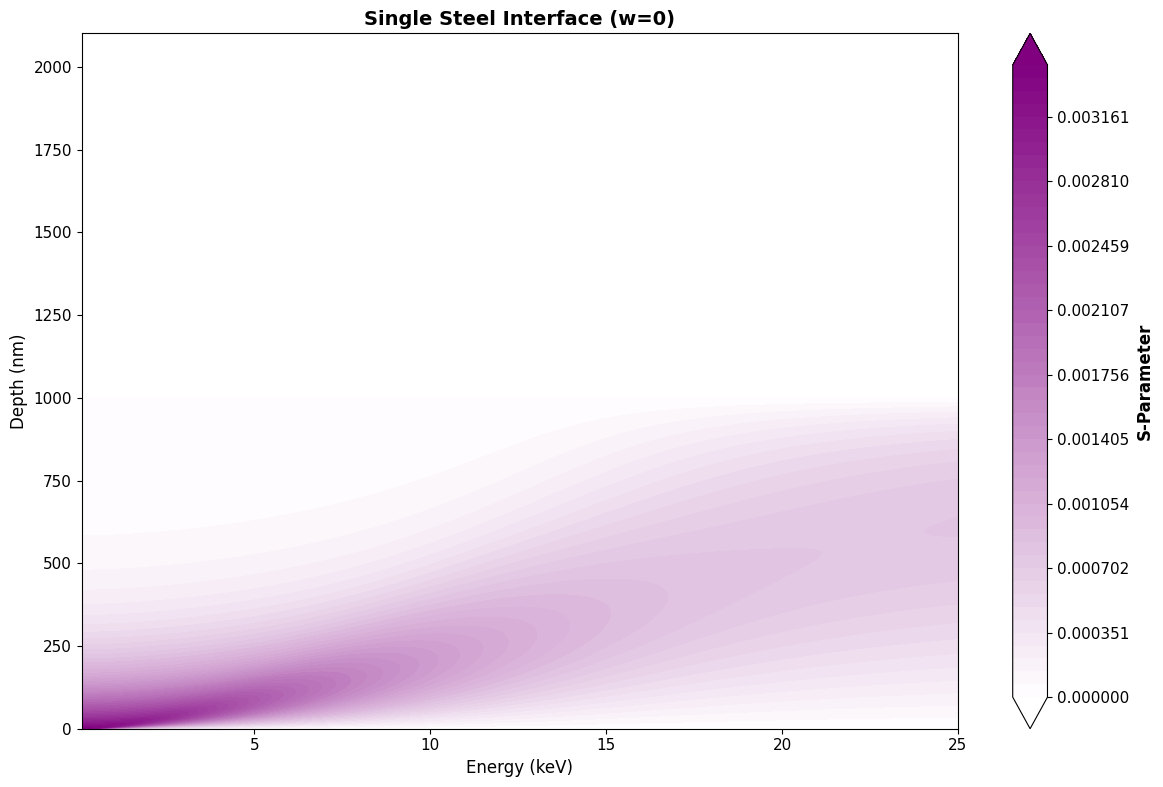

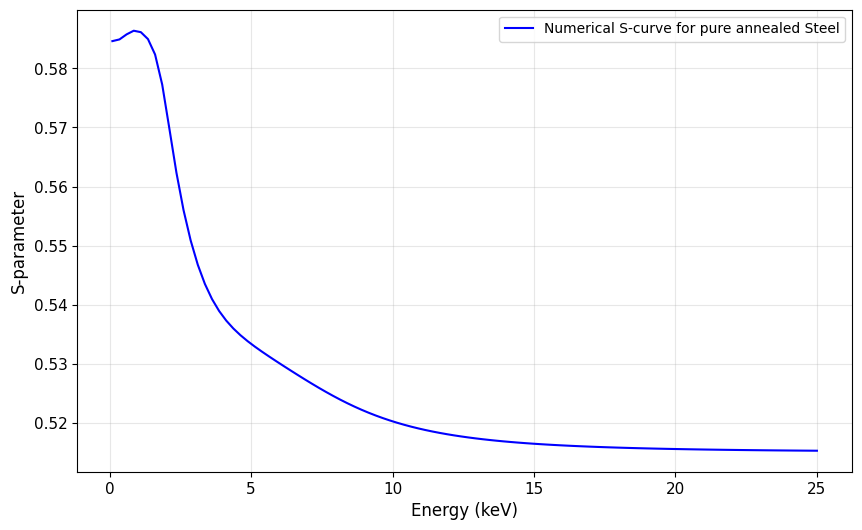

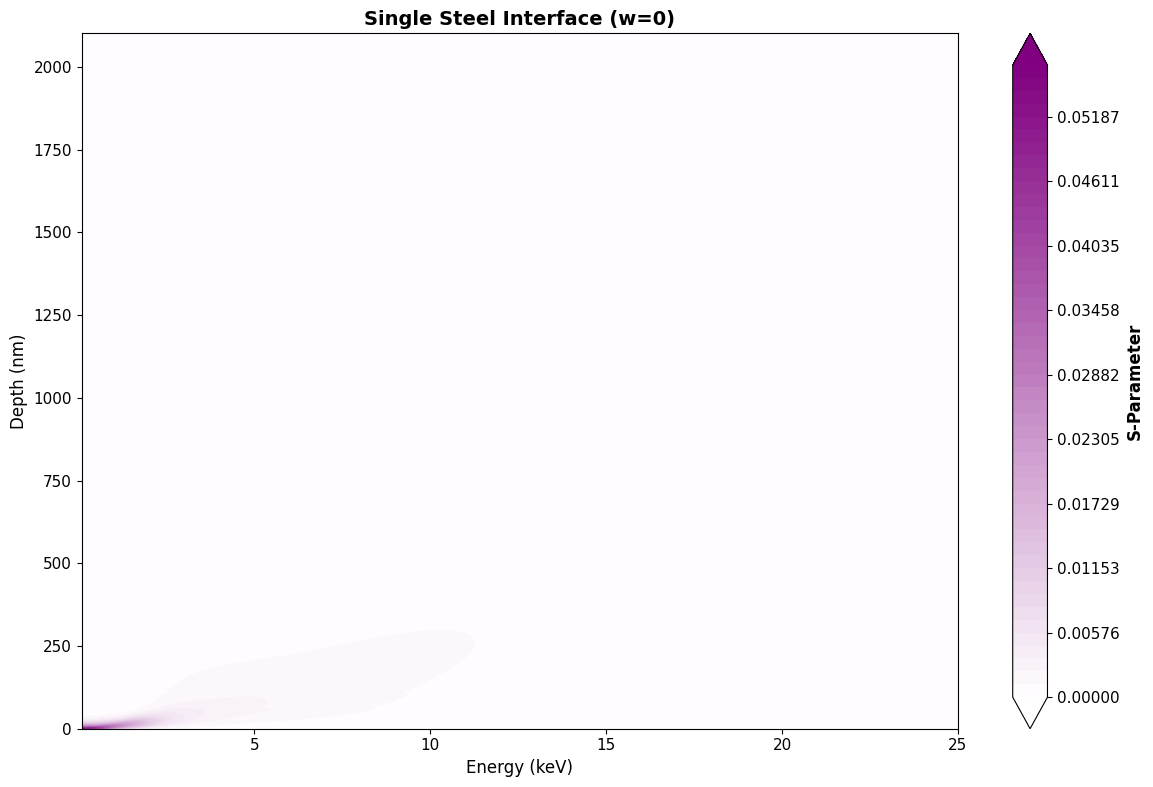

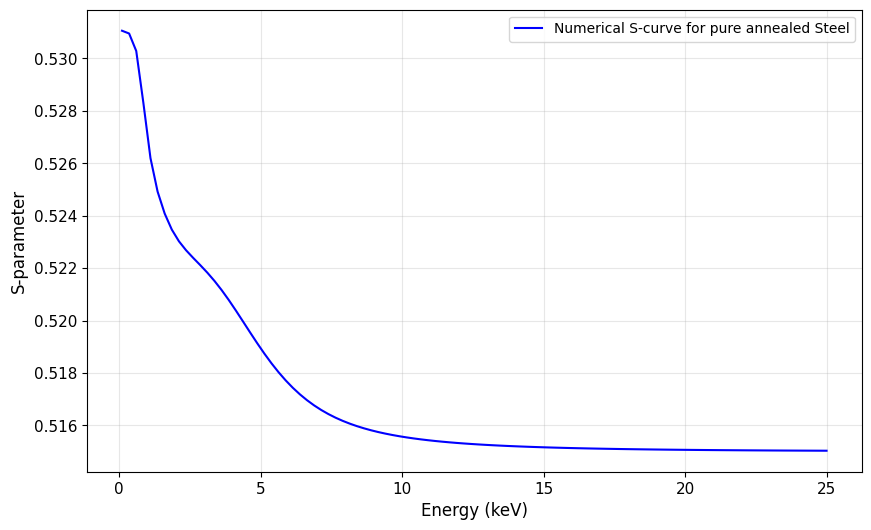

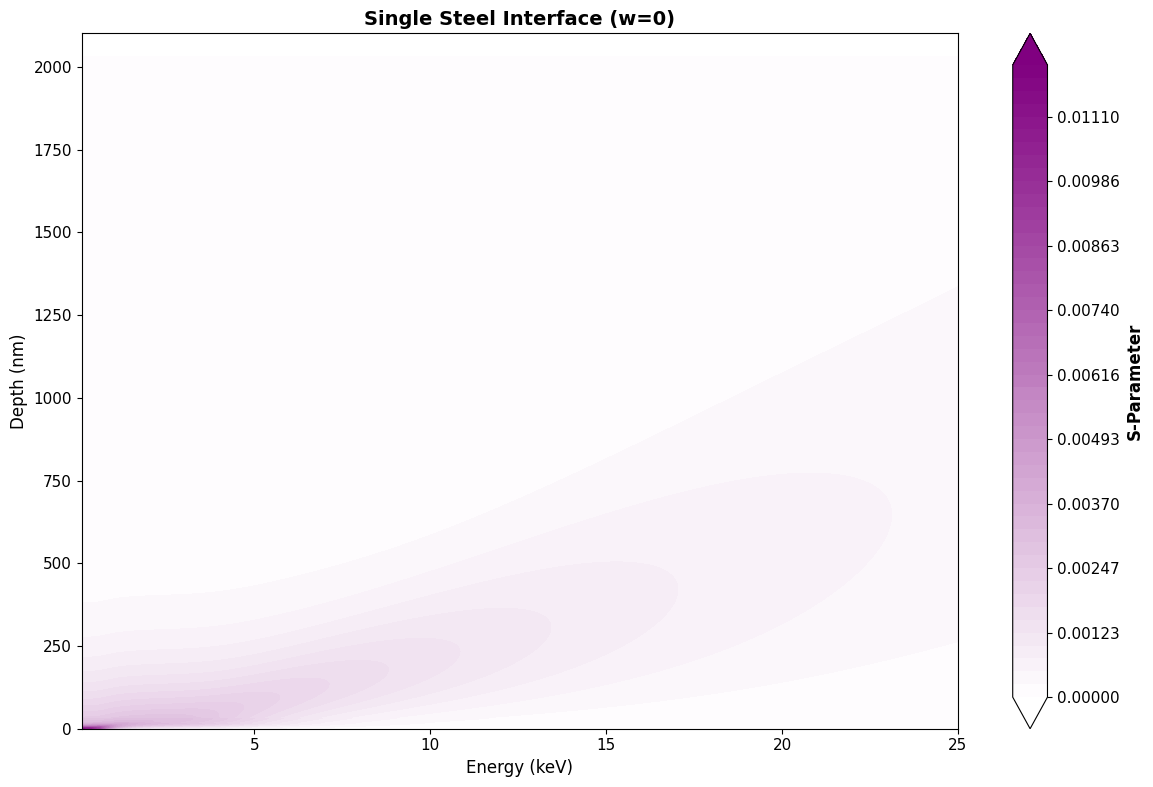

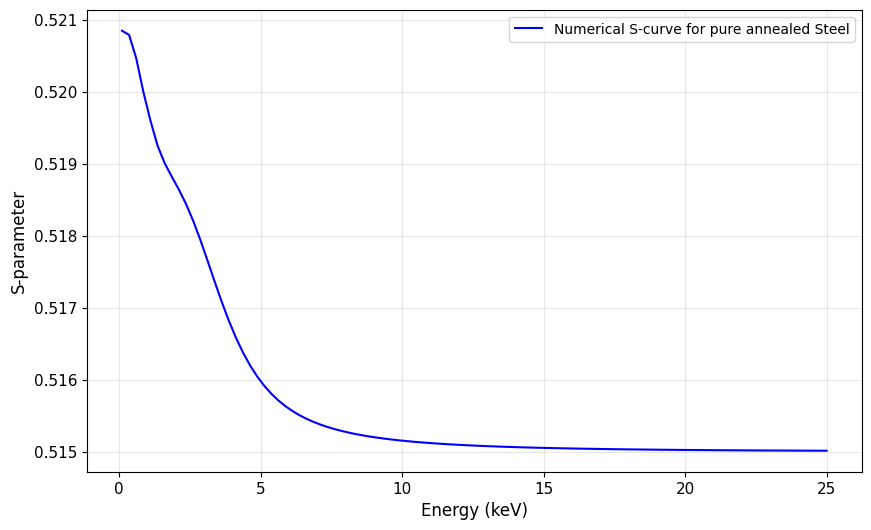

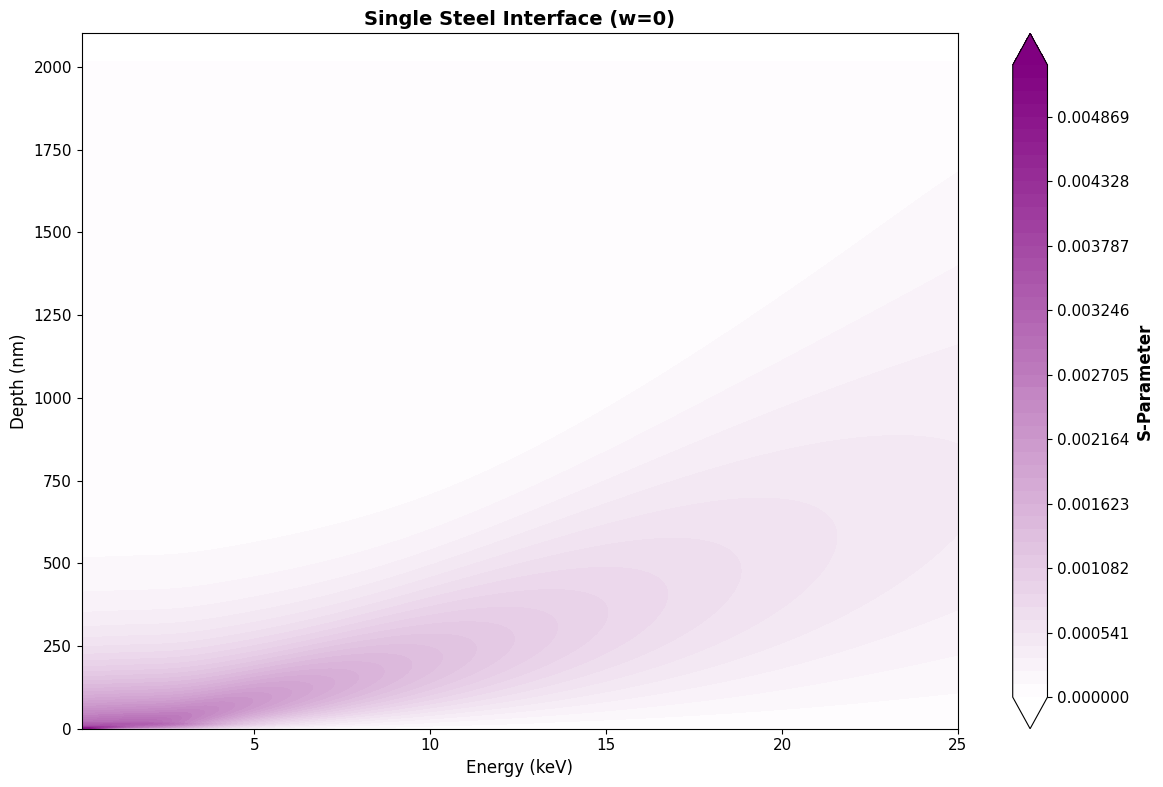

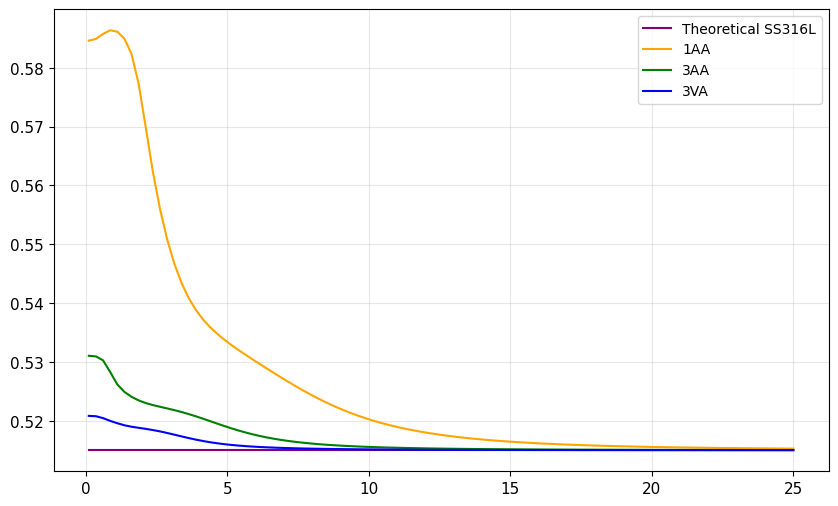

In [58]:
# We define the layer
S_steel, S_map_steel = numerical_S_curve(layers_steel, energies, w=5, model='layered', 
                                         z_max=d_max, 
                                         z_pts=z_pts
                                         )


S_1AA, S_map_1AA = numerical_S_curve(layers_1AA, energies, w=5, model='layered', 
                                         z_max=d_max, 
                                         z_pts=z_pts
                                         )


S_3AA, S_map_3AA = numerical_S_curve(layers_3AA, energies, w=5, model='layered', 
                                         z_max=d_max, 
                                         z_pts=z_pts
                                         )

S_3VA, S_map_3VA = numerical_S_curve(layers_3VA, energies, w=5, model='layered', 
                                         z_max=d_max, 
                                         z_pts=z_pts
                                         )


# Generate 2D Heatmap of S-parameter vs energy (keV) and thickness (nm)
# We also convert to a depth profile to ensure consistency.
matrix_sharp_steel = []
matrix_sharp_1AA = []
matrix_sharp_3AA = []
matrix_sharp_3VA = []

for E in energies:
# Run Sharp (Standard)
    p_steel = makhov_profile(z_grid, E, layers_steel, model='layered')
    p_1AA = makhov_profile(z_grid, E, layers_1AA, model='layered')
    p_3AA = makhov_profile(z_grid, E, layers_3AA, model='layered')
    p_3VA = makhov_profile(z_grid, E, layers_3VA, model='layered')
    c_steel = calculate_annihilation_profile(z_grid, p_steel, layers_steel, model='layered')
    c_1AA = calculate_annihilation_profile(z_grid, p_1AA, layers_1AA, model='layered')
    c_3AA = calculate_annihilation_profile(z_grid, p_3AA, layers_3AA, model='layered')
    c_3VA = calculate_annihilation_profile(z_grid, p_3VA, layers_3VA, model='layered')
    
    matrix_sharp_steel.append(c_steel * S_map_steel)
    matrix_sharp_1AA.append(c_1AA * S_map_1AA)
    matrix_sharp_3AA.append(c_3AA * S_map_3AA)
    matrix_sharp_3VA.append(c_3VA * S_map_3VA)


matrix_sharp_steel = np.array(matrix_sharp_steel)
S_fmap_steel = np.trapezoid(matrix_sharp_steel, z_grid, axis=1)

matrix_sharp_1AA = np.array(matrix_sharp_1AA)
S_fmap_1AA = np.trapezoid(matrix_sharp_1AA, z_grid, axis=1)

matrix_sharp_3AA = np.array(matrix_sharp_3AA)
S_fmap_3AA = np.trapezoid(matrix_sharp_3AA, z_grid, axis=1)

matrix_sharp_3VA = np.array(matrix_sharp_3VA)
S_fmap_3VA = np.trapezoid(matrix_sharp_3VA, z_grid, axis=1)


setup_plot_style()
plt.figure()
plt.plot(energies, S_steel, label="Numerical S-curve for pure annealed Steel", color='blue')
plt.xlabel("Energy (keV)")
plt.ylabel("S-parameter")
plt.legend()
plt.grid(True)

create_heatmap(
        energies, z_grid, matrix_sharp_steel,
        title="Single Steel Interface (w=0)",
        save_as="heatmap_sharp.pdf",
    )


setup_plot_style()
plt.figure()
plt.plot(energies, S_1AA, label="Numerical S-curve for pure annealed Steel", color='blue')
plt.xlabel("Energy (keV)")
plt.ylabel("S-parameter")
plt.legend()
plt.grid(True)

create_heatmap(
        energies, z_grid, matrix_sharp_1AA,
        title="Single Steel Interface (w=0)",
        save_as="heatmap_sharp.pdf",
    )

plt.figure()
plt.plot(energies, S_3AA, label="Numerical S-curve for pure annealed Steel", color='blue')
plt.xlabel("Energy (keV)")
plt.ylabel("S-parameter")
plt.legend()
plt.grid(True)

create_heatmap(
        energies, z_grid, matrix_sharp_3AA,
        title="Single Steel Interface (w=0)",
        save_as="heatmap_sharp.pdf",
    )

plt.figure()
plt.plot(energies, S_3VA, label="Numerical S-curve for pure annealed Steel", color='blue')
plt.xlabel("Energy (keV)")
plt.ylabel("S-parameter")
plt.legend()
plt.grid(True)

create_heatmap(
        energies, z_grid, matrix_sharp_3VA,
        title="Single Steel Interface (w=0)",
        save_as="heatmap_sharp.pdf",
    )

plt.figure()
plt.plot(energies, S_steel, label="Theoretical SS316L", color="purple")
plt.plot(energies, S_1AA, label="1AA", color='orange')
plt.plot(energies, S_3AA, label="3AA", color='green')
plt.plot(energies, S_3VA, label="3VA", color='blue')
plt.legend()
plt.grid(True)
plt.show()






In [59]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

colors = ["black", "grey", "red"] 
cmap_name = "steel_gradient"
n_bins = 100
norm = Normalize(vmin=0.0, vmax=1.0)
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

def overlapper(matrix_steel, z_grid_steel, matrix, z_grid, energies, c, surface_coverage=[0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]):
    matrix_steel_inter = np.zeros_like(matrix)
    for i, energy in enumerate(energies):
        # Get the row from the original Steel calculation
        steel_signal_row = matrix_steel[i, :]
        
        # INTERPOLATE:
        # "For every point in z_master, find the value based on (z_grid_steel, steel_signal_row)"
        # left=0, right=0 ensures we don't extrapolate into vacuum or deep bulk incorrectly
        interpolated_row = np.interp(z_grid, z_grid_steel, steel_signal_row, left=0, right=0)
        
        matrix_steel_inter[i, :] = interpolated_row

    setup_plot_style()
    S_overlap_tot = []
    # Surface coverage values iteration. Oxide coverage
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, c in enumerate(surface_coverage):
        matrix_overlap = (c * matrix) + ((1 - c) * matrix_steel_inter)
        S_overlap = np.trapezoid(matrix_overlap, z_grid, axis=1)
        current_color = custom_cmap(norm(c))
        ax.plot(energies, S_overlap, 
        label=f'{c*100} %', linewidth=2, color=current_color)
        S_overlap_tot.append(S_overlap)

    #ax.axvline(155, color='black', linestyle='--', alpha=0.5, label='Interface')
    ax.set_xlabel('Energy [keV]', fontsize=14)
    #ax.set_xlabel('Depth [nm]', fontsize=12, fontweight='bold')
    ax.set_ylabel('S-parameter [a.u]', fontsize=14)
    ax.set_title(f'Effect of oxide cover', 
                        fontsize=20, fontweight='bold')
    ax.legend()    
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    
    matrix_overlap = (c * matrix) + ((1 - c) * matrix_steel_inter)
    create_heatmap(energies, z_grid, matrix_overlap,
        title=f"Overlap Heatmap ({c*100}% Oxide Coverage)",
        save_as="heatmap_overlap_.pdf",
                )
    
    return S_overlap_tot, matrix_overlap


Saved: heatmap_overlap_.pdf
Saved: heatmap_overlap_.pdf
Saved: heatmap_overlap_.pdf


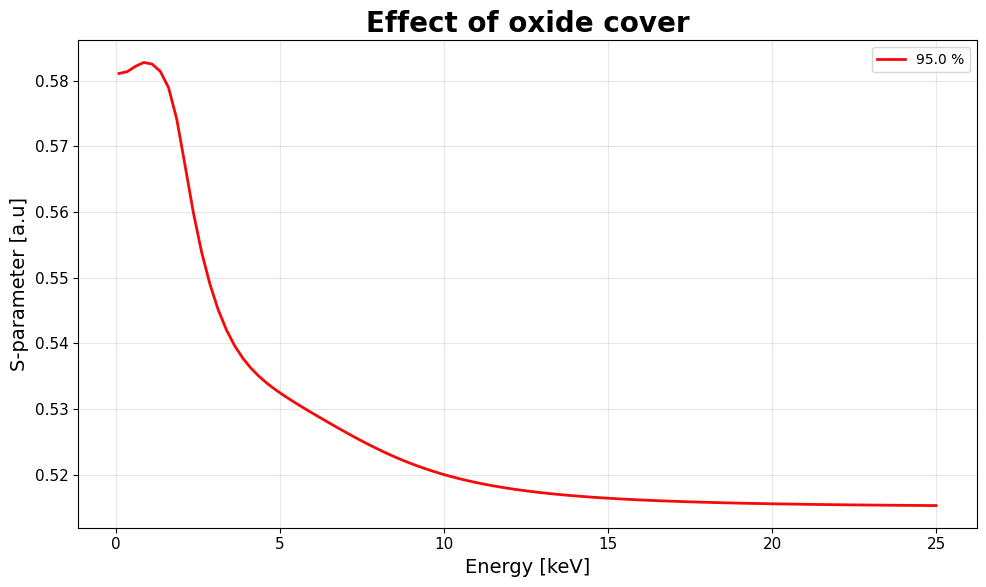

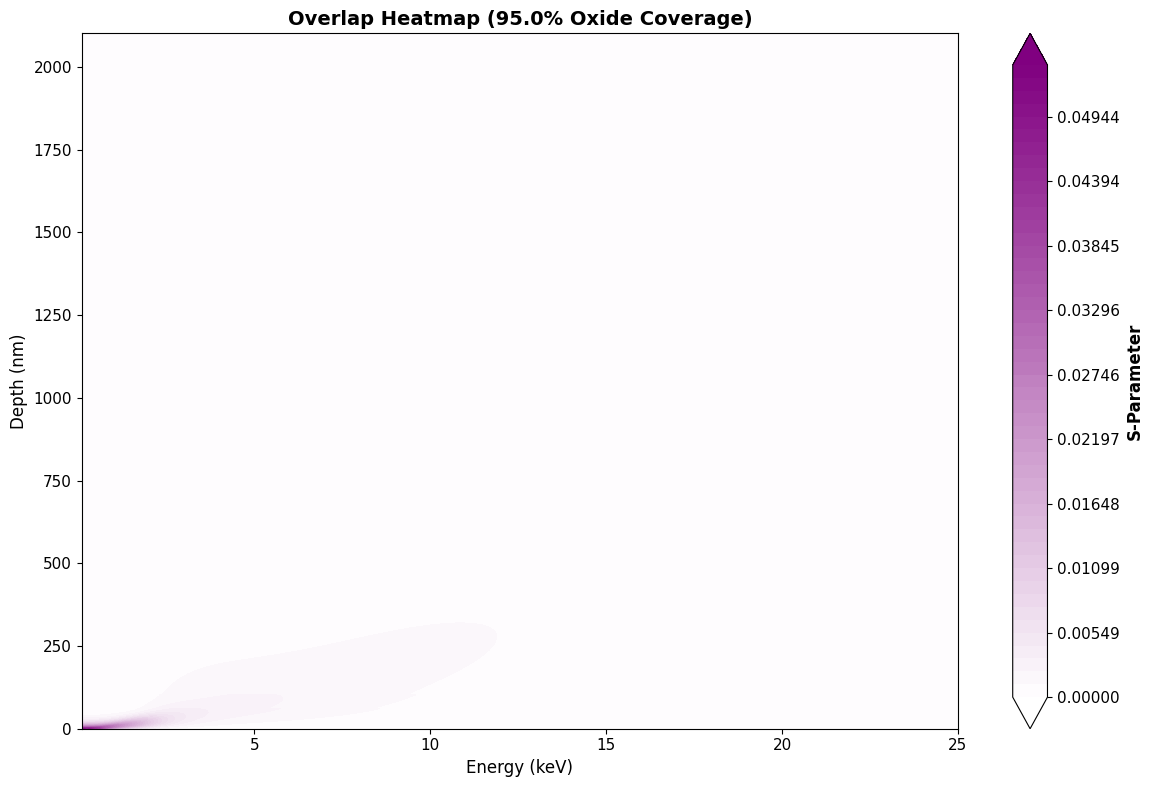

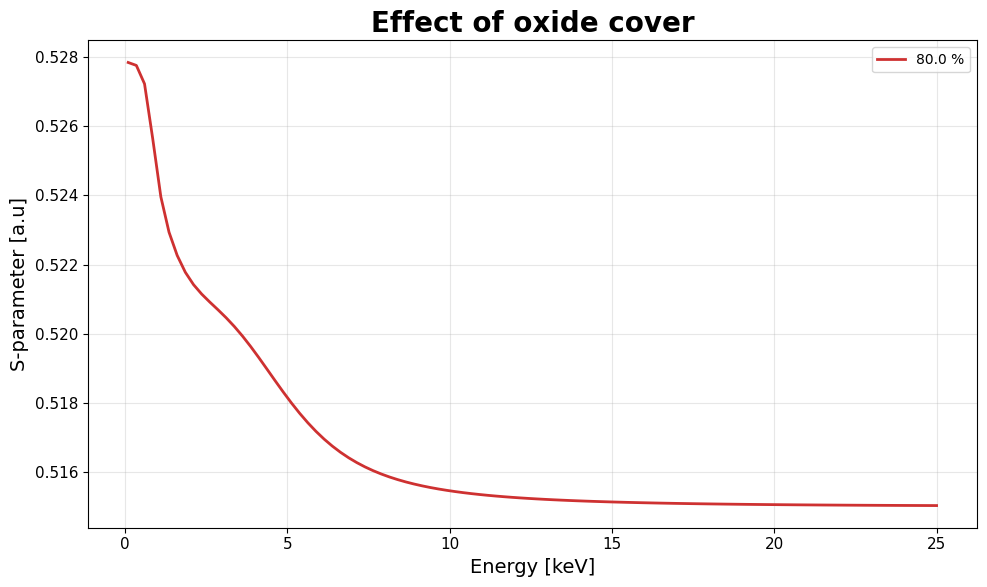

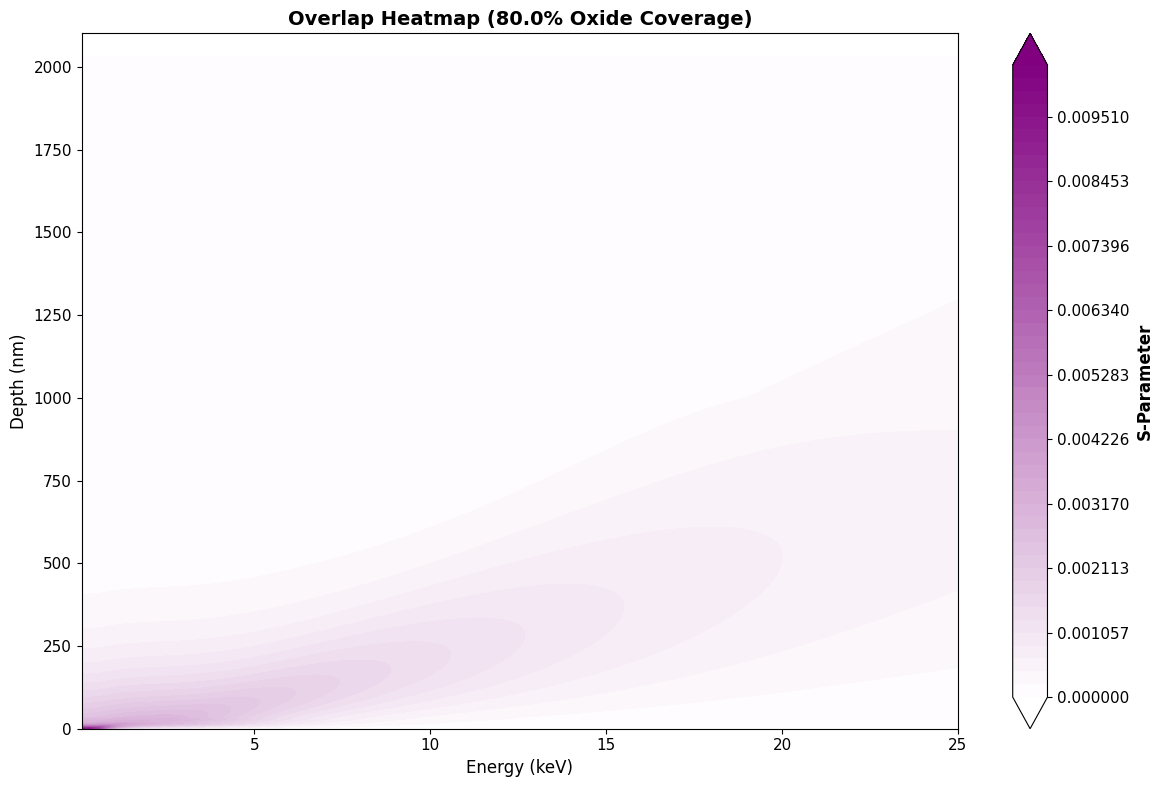

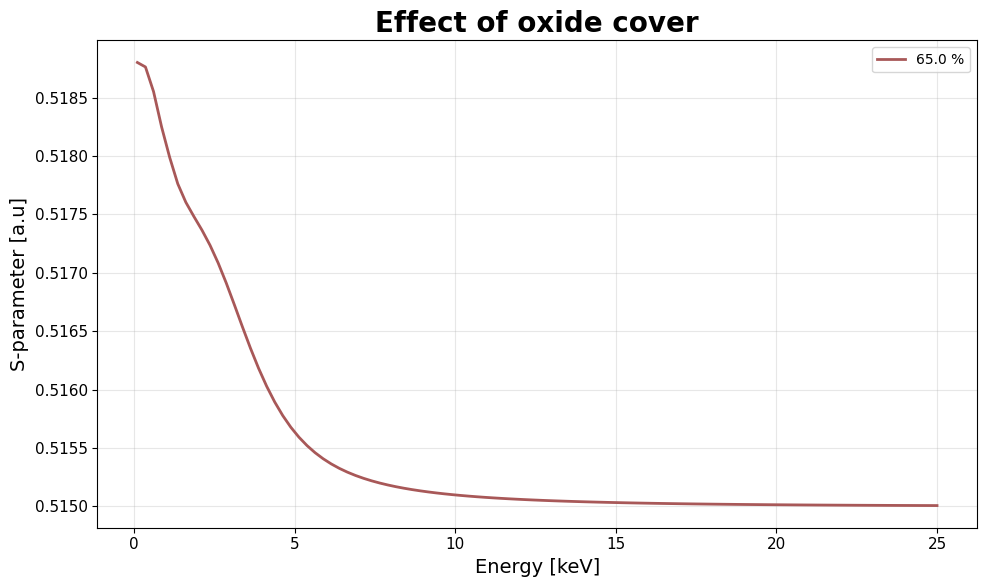

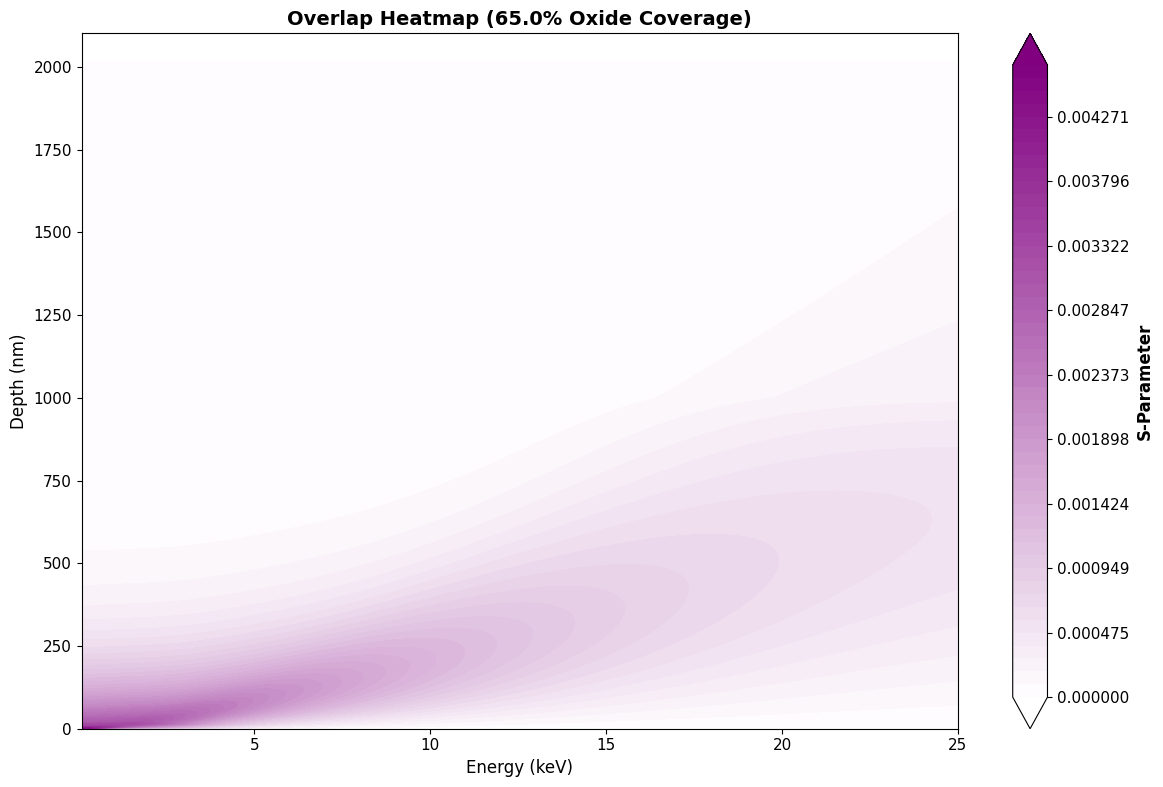

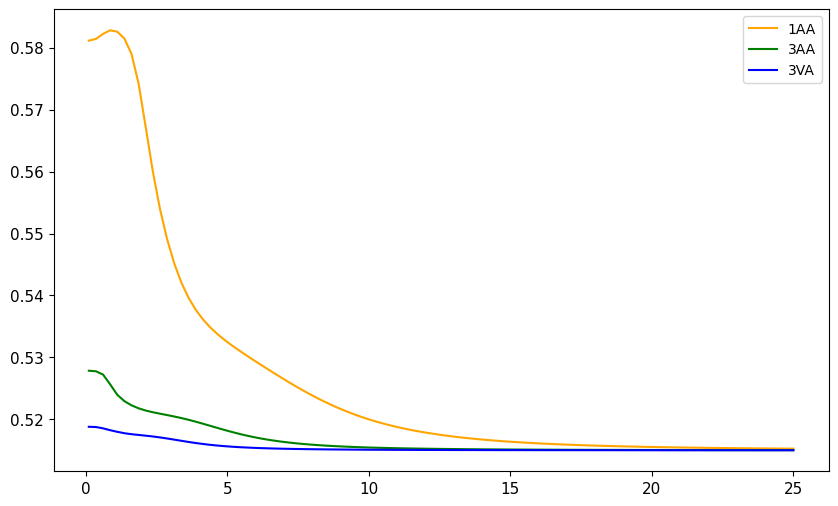

In [62]:

S_overlap_1AA, matrix_overlap_1AA = overlapper(matrix_sharp_steel, z_grid, matrix_sharp_1AA, z_grid, energies, 0.95, surface_coverage=[0.95])
S_overlap_3AA, matrix_overlap_3AA = overlapper(matrix_sharp_steel, z_grid, matrix_sharp_3AA, z_grid, energies, 0.80, surface_coverage=[0.80])
S_overlap_3VA, matrix_overlap_3VA = overlapper(matrix_sharp_steel, z_grid, matrix_sharp_3VA, z_grid, energies, 0.65, surface_coverage=[0.65])
plt.figure()
plt.plot(energies, S_overlap_1AA[0], color='orange', label="1AA")
plt.plot(energies, S_overlap_3AA[0], color='green', label="3AA")
plt.plot(energies, S_overlap_3VA[0], color='blue', label="3VA")
plt.legend()
